<a href="https://colab.research.google.com/github/dyjdlopez/mapua_ieemg_decision_science/blob/main/IE151P-S/Module%2002/02_02_linear_regression_assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02-02: Linear Regression — Inference, Assumptions, and Tests

**Companion to Lesson 2.1 (IE151P-S Advanced Computer Applications)** · Part 2 of 2 · about 90 minutes

Notebook 02-01 showed you how to fit a line and read the first half of the statsmodels summary. This notebook finishes the job: it explains **how sure we can be** about the numbers (standard errors, $t$, $F$, AIC/BIC), then checks whether the **assumptions behind OLS** actually hold, using the same tests as the lecture.

**By the end of this notebook you will be able to:**

1. Reproduce statsmodels' standard errors, $t$, $p$-values, confidence intervals, $F$, AIC, and BIC by hand.
2. Diagnose the five OLS assumptions (linearity, multicollinearity, independence, constant variance, normality) with a plot *and* a formal test.
3. Explain what each test's $H_0$ means and read its $p$-value correctly.
4. Apply a sensible remedy for each violation and check that it worked.
5. Run the whole diagnostic checklist on real data and on a dataset you have not seen.


## Part 0: Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import linear_reset, acorr_breusch_godfrey, het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson, jarque_bera, omni_normtest
from statsmodels.stats.outliers_influence import variance_inflation_factor

# statsmodels announces a future change to the return type of acorr_breusch_godfrey; silence it
warnings.filterwarnings("ignore", message="acorr_breusch_godfrey currently returns")

BLUE, RED, ORANGE, GREEN = "#1f618d", "#c0392b", "#e67e22", "#278a4d"
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

print("statsmodels:", statsmodels.__version__)

statsmodels: 0.15.0


## Part A: How Sure Are We? The Rest of the Summary

In Notebook 02-01 you decoded the model identity, $R^2$, adjusted $R^2$, and the `coef` column. What remains in the summary is the **inference** machinery:

| Summary field | Meaning | Section below |
|---|---|---|
| `std err` | Uncertainty of each coefficient | A.2 |
| `t`, `P>|t|`, `[0.025 0.975]` | $t$-test and 95% confidence interval | A.3 |
| `F-statistic`, `Prob (F-statistic)` | Overall significance test | A.4 |
| `Log-Likelihood`, `AIC`, `BIC` | Model comparison criteria | A.5 |

We use the same 10-plot rice trial as the lecture (illustrative data, not actual IRRI measurements), refit with the formula interface.

In [ ]:
N_rate = np.array([0, 25, 50, 50, 75, 100, 100, 125, 150, 150], dtype=float)
grain_yield = np.array([3300, 3600, 4500, 4150, 4800, 5300, 5650, 5800, 6700, 6100], dtype=float)
rice = pd.DataFrame({"N_rate_kg_ha": N_rate, "yield_kg_ha": grain_yield},
                    index=pd.RangeIndex(1, 11, name="plot"))

results = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data=rice).fit()
x, y = N_rate, grain_yield
n, p = len(x), 1                      # n observations, p predictors
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            yield_kg_ha   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     230.7
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           3.50e-07
Time:                        06:56:30   Log-Likelihood:                -66.816
No. Observations:                  10   AIC:                             137.6
Df Residuals:                       8   BIC:                             138.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3237.7953    134.026     24.158   

### A.1 Error metrics: how big are the misses?

Before we ask how sure we are about the *coefficients*, we ask how big the typical *prediction miss* is. All four metrics start from the residuals $e_i$:

| Metric | Formula | Plain-language meaning |
|---|---|---|
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum e_i^2$ | Average squared miss, in (kg/ha)² |
| **RMSE** (Root Mean Squared Error) | $\sqrt{\text{MSE}}$ | Typical miss in yield units; punishes large misses |
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum \lvert e_i\rvert$ | Average absolute miss; less sensitive to outliers |
| **$s$** (standard error of the estimate) | $\sqrt{\text{SSE}/(n-p-1)}$ | RMSE corrected for degrees of freedom; estimates the error SD $\sigma$ |

$s$ is the quantity every standard error below is built from. statsmodels stores $s^2$ as `results.mse_resid`.

In [ ]:
resid = results.resid.to_numpy()
SSE = np.sum(resid ** 2)

MSE  = SSE / n
RMSE = np.sqrt(MSE)
MAE  = np.mean(np.abs(resid))
s    = np.sqrt(SSE / (n - p - 1))

display(pd.DataFrame({
    "value": [MSE, RMSE, MAE, s],
    "units": ["(kg/ha)²", "kg/ha", "kg/ha", "kg/ha"],
}, index=["MSE", "RMSE", "MAE", "s"]).round(2))

print(f"RMSE ≥ MAE always; a bigger gap means a few large misses (here {RMSE:.0f} vs {MAE:.0f}).")
print(f"s = {s:.2f} kg/ha is about {100 * s / y.mean():.1f}% of the mean yield.")

assert np.isclose(s, np.sqrt(results.mse_resid))

,value,units
MSE,37245.41,(kg/ha)²
RMSE,192.99,kg/ha
MAE,165.43,kg/ha
s,215.77,kg/ha


RMSE ≥ MAE always; a bigger gap means a few large misses (here 193 vs 165).
s = 215.77 kg/ha is about 4.3% of the mean yield.


### A.2 Standard errors: how much would the estimate wobble?

A **standard error** (SE) says how much a coefficient would typically change if we repeated the trial with new plots. For simple regression:

$$\text{SE}(\hat\beta_1) = \frac{s}{\sqrt{S_{xx}}}, \qquad \text{SE}(\hat\beta_0) = s\sqrt{\frac{1}{n}+\frac{\bar{x}^2}{S_{xx}}}$$

where $S_{xx} = \sum (x_i-\bar{x})^2$. **Plain language:** less noise ($s$ small) and more spread in $x$ ($S_{xx}$ large) both make the slope more precise.

In [ ]:
S_xx = np.sum((x - x.mean()) ** 2)
se_b1 = s / np.sqrt(S_xx)
se_b0 = s * np.sqrt(1 / n + x.mean() ** 2 / S_xx)

compare = pd.DataFrame({
    "by hand": [se_b0, se_b1],
    "results.bse": results.bse.to_numpy(),
}, index=["Intercept", "N_rate_kg_ha"])
display(compare.round(4))

assert np.allclose(compare["by hand"], compare["results.bse"])

,by hand,results.bse
Intercept,134.0255,134.0255
N_rate_kg_ha,1.3983,1.3983


### A.3 The $t$-test, $p$-value, and confidence interval

To ask whether N rate really affects yield, we test $H_0: \beta_1 = 0$ (no linear effect) against $H_1: \beta_1 \neq 0$.

$$t = \frac{\hat\beta_j}{\text{SE}(\hat\beta_j)}, \qquad \text{df} = n-p-1$$

**Plain language:** $t$ counts how many standard errors the estimate lies from zero. The two-sided **$p$-value** is the chance of a $\lvert t\rvert$ at least this large if $H_0$ were true, and the **95% confidence interval** is $\hat\beta_j \pm t_{0.025,\,\text{df}}\cdot\text{SE}(\hat\beta_j)$.

In [ ]:
b = results.params.to_numpy()
se = np.array([se_b0, se_b1])
dof = n - p - 1

t_stat = b / se
p_val = 2 * stats.t.sf(np.abs(t_stat), dof)          # two-sided
t_crit = stats.t.ppf(0.975, dof)
ci_low, ci_high = b - t_crit * se, b + t_crit * se

print(f"Degrees of freedom = {dof};  critical t (95%) = {t_crit:.3f}\n")
for name, bi, ti, pi, lo, hi in zip(["Intercept", "N_rate_kg_ha"], b, t_stat, p_val, ci_low, ci_high):
    print(f"{name:13s} coef = {bi:9.3f}   t = {ti:6.2f}   p = {pi:.2e}   95% CI = [{lo:,.1f}, {hi:,.1f}]")

assert np.allclose(t_stat, results.tvalues) and np.allclose(p_val, results.pvalues)
assert np.allclose(np.column_stack([ci_low, ci_high]), results.conf_int().to_numpy())
print("\nAll match statsmodels. |t| > critical value, so reject H0: N rate has a real linear effect on yield.")

Degrees of freedom = 8;  critical t (95%) = 2.306

Intercept     coef =  3237.795   t =  24.16   p = 9.19e-09   95% CI = [2,928.7, 3,546.9]
N_rate_kg_ha  coef =    21.239   t =  15.19   p = 3.50e-07   95% CI = [18.0, 24.5]

All match statsmodels. |t| > critical value, so reject H0: N rate has a real linear effect on yield.


### A.4 The $F$-test: is the model better than nothing?

The $t$-test judges one coefficient. The **$F$-test** judges the *whole model*: $H_0: \beta_1=\dots=\beta_p=0$, meaning the model is no better than predicting $\bar{y}$ for every plot.

$$F = \frac{\text{MSR}}{\text{MSE}} = \frac{\text{SSR}/p}{\text{SSE}/(n-p-1)} \sim F(p,\; n-p-1)$$

**Plain language:** MSR is the explained variation *per predictor* and MSE is the unexplained variation *per residual degree of freedom*. A large ratio means the model explains far more than noise would. With one predictor, $F = t^2$.

In [ ]:
SSR = np.sum((results.fittedvalues - y.mean()) ** 2)
MSR, MSE_r = SSR / p, SSE / (n - p - 1)
F_stat = MSR / MSE_r
p_F = stats.f.sf(F_stat, p, n - p - 1)

print(f"F = {MSR:,.0f} / {MSE_r:,.0f} = {F_stat:.1f}   (p = {p_F:.2e})")
print(f"t² for the slope = {t_stat[1] ** 2:.1f}  (equals F in simple regression)")
display(sm.stats.anova_lm(results))        # the classic ANOVA table

assert np.isclose(F_stat, results.fvalue) and np.isclose(F_stat, t_stat[1] ** 2)
assert np.isclose(p_F, results.f_pvalue)

F = 10,741,546 / 46,557 = 230.7   (p = 3.50e-07)
t² for the slope = 230.7  (equals F in simple regression)


,df,sum_sq,mean_sq,F,PR(>F)
N_rate_kg_ha,1.0,1.074155e+07,1.074155e+07,230.719369,3.496018e-07
Residual,8.0,3.724541e+05,4.655676e+04,NaN,NaN


### A.5 Log-likelihood, AIC, and BIC

**AIC** (Akaike Information Criterion) and **BIC** (Bayesian Information Criterion, also called the Schwarz criterion) score a model by its fit minus a penalty for complexity. **Lower is better.**

$$\text{AIC} = 2k - 2\ln\hat{L}, \qquad \text{BIC} = k\ln n - 2\ln\hat{L}$$

$k$ is the number of estimated coefficients (here $p+1$) and $\hat{L}$ is the maximized likelihood. For OLS with normal errors, $-2\ln\hat{L} = n\,[\ln(2\pi) + \ln(\text{SSE}/n) + 1]$. The lecture used the shorter form $n\ln(\text{SSE}/n) + 2k$, which drops the constant $n(1+\ln 2\pi)$. That constant is the same for every model fitted to the same data, so **differences between models are identical**; only the absolute numbers differ.

In [ ]:
k = p + 1
llf = -n / 2 * (np.log(2 * np.pi) + np.log(SSE / n) + 1)
aic, bic = 2 * k - 2 * llf, k * np.log(n) - 2 * llf
print(f"Log-likelihood = {llf:.3f}   AIC = {aic:.3f}   BIC = {bic:.3f}")
assert np.isclose(llf, results.llf) and np.isclose(aic, results.aic) and np.isclose(bic, results.bic)

# Compare three models, as on the lecture's AIC/BIC slide
rice_noise = rice.assign(noise=np.random.default_rng(1).normal(size=n))
formulas = {
    "1: N":               "yield_kg_ha ~ N_rate_kg_ha",
    "2: N + random noise": "yield_kg_ha ~ N_rate_kg_ha + noise",
    "3: N + N²":           "yield_kg_ha ~ N_rate_kg_ha + I(N_rate_kg_ha**2)",
}
rows = []
for name, f in formulas.items():
    m = smf.ols(f, rice_noise).fit()
    k_, sse = int(m.df_model) + 1, np.sum(m.resid ** 2)
    rows.append({"model": name, "k": k_, "SSE": sse,
                 "AIC (statsmodels)": m.aic, "BIC (statsmodels)": m.bic,
                 "AIC (slide form)": n * np.log(sse / n) + 2 * k_,
                 "BIC (slide form)": n * np.log(sse / n) + k_ * np.log(n)})
cmp = pd.DataFrame(rows).set_index("model")
display(cmp.round(1))

offset = cmp["AIC (statsmodels)"] - cmp["AIC (slide form)"]
assert np.allclose(offset, offset.iloc[0])
print(f"\nThe two AIC versions differ by the same constant for every model: {offset.iloc[0]:.2f} = n(1 + ln 2π).")
print("Model 1 has the lowest AIC and BIC: the extra parameter in models 2 and 3 does not pay its penalty.")

Log-likelihood = -66.816   AIC = 137.632   BIC = 138.237


,k,SSE,AIC (statsmodels),BIC (statsmodels),AIC (slide form),BIC (slide form)
model,,,,,,
1: N,2,372454.1,137.6,138.2,109.3,109.9
2: N + random noise,3,369146.9,139.5,140.5,111.2,112.1
3: N + N²,3,369126.9,139.5,140.4,111.2,112.1



The two AIC versions differ by the same constant for every model: 28.38 = n(1 + ln 2π).
Model 1 has the lowest AIC and BIC: the extra parameter in models 2 and 3 does not pay its penalty.


**Decoder complete.** You can now read every field in the top two blocks and the coefficient table of `results.summary()`. The bottom block (Omnibus, Skew, Kurtosis, Durbin-Watson, Jarque-Bera, Cond. No.) belongs to Part B.

### Your turn

Compute the **90% confidence interval** for the slope by hand (hint: use `stats.t.ppf(0.95, dof)`) and check it against `results.conf_int(alpha=0.10)`.

In [ ]:
# YOUR TURN
# 1. t90 = stats.t.ppf(0.95, dof)
# 2. ci90 = (slope - t90 * se_slope, slope + t90 * se_slope)
# 3. Compare with results.conf_int(alpha=0.10).loc["N_rate_kg_ha"]

In [ ]:
# SOLUTION: try it yourself first
t90 = stats.t.ppf(0.95, dof)
ci90 = (b[1] - t90 * se_b1, b[1] + t90 * se_b1)
print(f"90% CI by hand: [{ci90[0]:.2f}, {ci90[1]:.2f}]   (t = {t90:.3f})")
print("statsmodels   :", results.conf_int(alpha=0.10).loc["N_rate_kg_ha"].round(2).tolist())
assert np.allclose(ci90, results.conf_int(alpha=0.10).loc["N_rate_kg_ha"])
print("A 90% interval is narrower than the 95% one [18.01, 24.46]: less confidence, tighter range.")

90% CI by hand: [18.64, 23.84]   (t = 1.860)
statsmodels   : [18.64, 23.84]
A 90% interval is narrower than the 95% one [18.01, 24.46]: less confidence, tighter range.


## Part B: The Assumption Lab

OLS gives trustworthy answers only when its assumptions hold. Here are the five from the lecture, the test for each, and where each one shows up in the summary:

| Assumption | Violation is called | Test(s) in this notebook | Summary field |
|---|---|---|---|
| Linearity | Misspecification | Ramsey RESET | none |
| No perfect multicollinearity | Multicollinearity | VIF | `Cond. No.` |
| Independent errors | Autocorrelation | Durbin–Watson, Breusch–Godfrey | `Durbin-Watson` |
| Constant variance | Heteroskedasticity | Breusch–Pagan, White | none |
| Normal errors | Non-normality | Shapiro–Wilk, Jarque–Bera | `Omnibus`, `Skew`, `Kurtosis`, `Jarque-Bera` |

**Workflow for every assumption:** *predict* what you expect, *run* the plot and test, *interpret* the result, then apply a *remedy* and check it worked.

**Reading the tests.** In nearly all of these tests $H_0$ says *the assumption holds*. So a **small $p$-value (below $\alpha = 0.05$) is the bad news**: it is evidence the assumption is violated. A large $p$-value means only "no evidence against", not proof that the assumption is true.

### About the datasets in this part

Each lab uses a **synthetic** dataset built to show exactly one violation, so that you can see what each problem looks like. They are the same datasets as the lecture's check slides (values embedded and rounded to 2 decimals), so your numbers should match the slides. How they were made:

| Lab | How the data were generated |
|---|---|
| Linearity | yield $= 3200 + 42N - 0.15N^2$ + noise (SD 110): yield plateaus |
| Multicollinearity | $P \approx 0.4N$ + noise, yield $= 3200 + 14N + 25P$ + noise: N and P move together |
| Independence | errors follow an AR(1) process with $\rho = 0.8$ along a row of 20 plots |
| Constant variance | error SD grows with N: $15 + 2.2N$ |
| Normality | heavy-tailed errors ($t$ distribution with 2.5 df) |

*Remember the lesson from Anscombe's quartet first.*

### B.0 Anscombe's quartet: why we check

Anscombe (1973) built four tiny datasets with **identical** summary statistics. If summary numbers were enough, all four would be equally trustworthy.

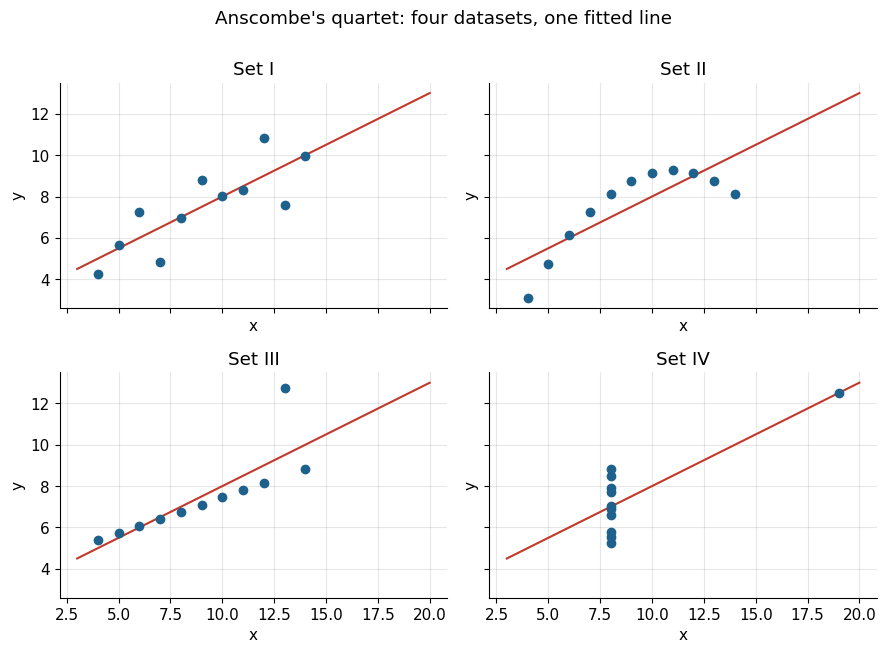

,mean x,mean y,intercept,slope,R²
set,,,,,
I,9.0,7.5,3.0,0.5,0.67
II,9.0,7.5,3.0,0.5,0.67
III,9.0,7.5,3.0,0.5,0.67
IV,9.0,7.5,3.0,0.5,0.67


In [ ]:
x123 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
anscombe = pd.DataFrame({
    "set": ["I"] * 11 + ["II"] * 11 + ["III"] * 11 + ["IV"] * 11,
    "x": x123 * 3 + [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
    "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68,
          9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74,
          7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73,
          6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
})

rows, fig, axes = [], *plt.subplots(2, 2, figsize=(9, 6.5), sharex=True, sharey=True)
for ax, (name, g) in zip(axes.ravel(), anscombe.groupby("set")):
    fit = smf.ols("y ~ x", g).fit()
    rows.append({"set": name, "mean x": g.x.mean(), "mean y": g.y.mean(),
                  "intercept": fit.params.iloc[0], "slope": fit.params.iloc[1], "R²": fit.rsquared})
    ax.scatter(g.x, g.y, color=BLUE, zorder=3)
    xs = np.array([3, 20])
    ax.plot(xs, fit.params.iloc[0] + fit.params.iloc[1] * xs, color=RED)
    ax.set_title(f"Set {name}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.suptitle("Anscombe's quartet: four datasets, one fitted line", y=1.0)
fig.tight_layout()
plt.show()
display(pd.DataFrame(rows).set_index("set").round(2))

The table is (almost) identical for all four sets: mean $x$ = 9, mean $y$ = 7.5, line $\hat{y} = 3.00 + 0.50x$, $R^2 \approx 0.67$. The pictures are not. Set I is a fair straight-line fit, II is curved, III has one outlier dragging the line, and IV has one high-leverage point creating the whole slope. **Fit statistics cannot validate a model; assumption checks (plots and tests) can.**

### B.1 Linearity

**Assumption:** the mean of $y$ is a linear function of the *parameters* $\beta$ (so an $N^2$ column is allowed; a curve that no straight line can follow is not). **Violation:** model misspecification.

**Plot:** residuals vs. fitted values. A random cloud around zero is healthy; a curve means the line is the wrong shape.

**Test: Ramsey RESET.** Refit the model with $\hat{y}^2$ added, then $F$-test whether the extra term matters. $H_0$: no omitted nonlinearity (the form is correct).

*Dataset:* 11 plots where rice yield **plateaus** at high nitrogen.

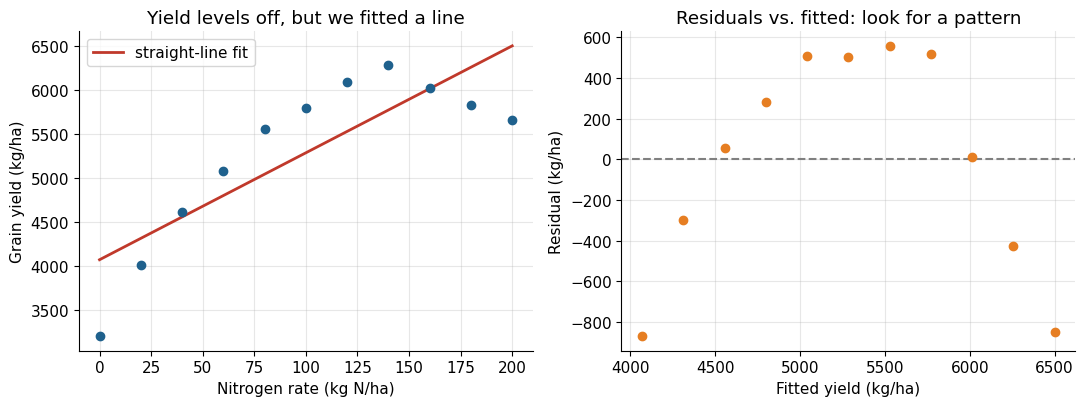

R² = 0.690


In [ ]:
data_A = pd.DataFrame({
    "N_rate_kg_ha": [
    0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0,
    160.0, 180.0, 200.0,
],
    "yield_kg_ha": [
    3200.14, 4012.86, 4609.84, 5082.03, 5549.99, 5790.92, 6086.62, 6287.42,
    6025.86, 5831.75, 5653.88,
],
})
res_a = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data_A).fit()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(data_A.N_rate_kg_ha, data_A.yield_kg_ha, color=BLUE, zorder=3)
grid = np.array([0, 200])
axes[0].plot(grid, res_a.params.iloc[0] + res_a.params.iloc[1] * grid, color=RED, lw=2, label="straight-line fit")
axes[0].set_xlabel("Nitrogen rate (kg N/ha)"); axes[0].set_ylabel("Grain yield (kg/ha)")
axes[0].set_title("Yield levels off, but we fitted a line"); axes[0].legend()

axes[1].scatter(res_a.fittedvalues, res_a.resid, color=ORANGE, zorder=3)
axes[1].axhline(0, color="gray", ls="--")
axes[1].set_xlabel("Fitted yield (kg/ha)"); axes[1].set_ylabel("Residual (kg/ha)")
axes[1].set_title("Residuals vs. fitted: look for a pattern")
fig.tight_layout()
plt.show()
print(f"R² = {res_a.rsquared:.3f}")

**Predict first.** The residuals form an inverted U: negative at both ends and positive in the middle. What do you expect RESET to say? Run it, and also build it by hand ($\hat{y}^2$ added, then the $F$-test comparing SSE of the two models).

In [ ]:
reset = linear_reset(res_a, power=2, use_f=True)
print(f"RESET (statsmodels): F = {reset.fvalue:.1f},  p = {reset.pvalue:.2g}")

# By hand: add fitted², compare the two models' SSE
data_A2 = data_A.assign(fitted_sq=res_a.fittedvalues ** 2)
res_u = smf.ols("yield_kg_ha ~ N_rate_kg_ha + fitted_sq", data_A2).fit()
sse_r, sse_u = np.sum(res_a.resid ** 2), np.sum(res_u.resid ** 2)
F_hand = ((sse_r - sse_u) / 1) / (sse_u / res_u.df_resid)
print(f"RESET (by hand)    : F = {F_hand:.1f},  p = {stats.f.sf(F_hand, 1, res_u.df_resid):.2g}")

assert np.isclose(F_hand, reset.fvalue)
print("\np is far below 0.05: reject H0. The straight-line form is wrong for this data.")

RESET (statsmodels): F = 454.0,  p = 2.5e-08
RESET (by hand)    : F = 454.0,  p = 2.5e-08

p is far below 0.05: reject H0. The straight-line form is wrong for this data.


**Remedy.** Add an $N^2$ term so the model can bend (it is still *linear regression*, because it is linear in the parameters). Then re-check the residuals and re-run RESET.

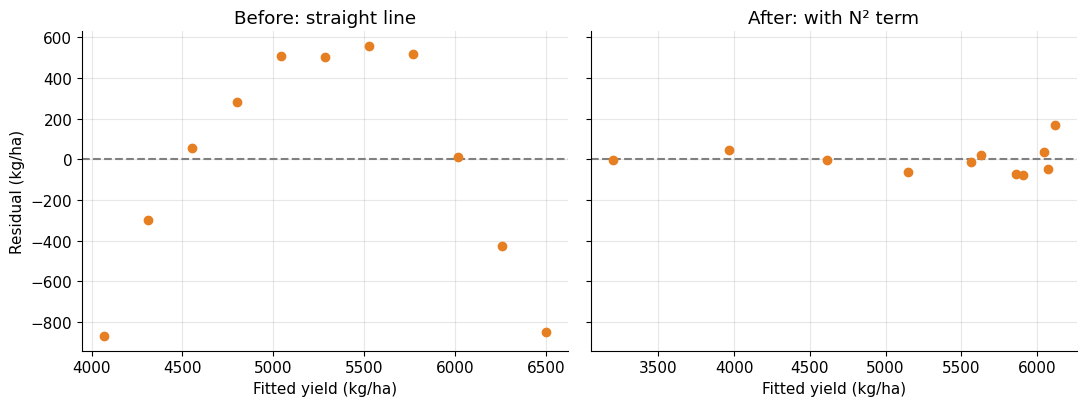

RESET after the fix: F = 0.48, p = 0.51  (no evidence against linearity now)
R²: 0.690 -> 0.995;  adjusted R²: 0.656 -> 0.993


In [ ]:
res_a2 = smf.ols("yield_kg_ha ~ N_rate_kg_ha + I(N_rate_kg_ha**2)", data_A).fit()
reset2 = linear_reset(res_a2, power=2, use_f=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, res, title in zip(axes, [res_a, res_a2], ["Before: straight line", "After: with N² term"]):
    ax.scatter(res.fittedvalues, res.resid, color=ORANGE, zorder=3)
    ax.axhline(0, color="gray", ls="--")
    ax.set_xlabel("Fitted yield (kg/ha)"); ax.set_title(title)
axes[0].set_ylabel("Residual (kg/ha)")
fig.tight_layout()
plt.show()

print(f"RESET after the fix: F = {reset2.fvalue:.2f}, p = {reset2.pvalue:.2f}  (no evidence against linearity now)")
print(f"R²: {res_a.rsquared:.3f} -> {res_a2.rsquared:.3f};  adjusted R²: {res_a.rsquared_adj:.3f} -> {res_a2.rsquared_adj:.3f}")
assert reset.pvalue < 0.001 and reset2.pvalue > 0.05

### B.2 No perfect multicollinearity

**Assumption:** no predictor is an exact linear combination of the others. **Violation:** *multicollinearity*. *Perfect* multicollinearity makes $X^\top X$ singular, so no unique solution exists; *imperfect* multicollinearity (predictors nearly redundant) still gives estimates, but unstable ones.

**Measure: VIF** (Variance Inflation Factor). Regress predictor $x_j$ on all the *other* predictors and take that regression's $R_j^2$:

$$\text{VIF}_j = \frac{1}{1-R_j^2}, \qquad \text{SE}(\hat\beta_j) \text{ grows by a factor of } \sqrt{\text{VIF}_j}$$

**Plain language:** $R_j^2$ is the share of $x_j$ already explained by the other predictors. Rules of thumb: VIF above 5 is a concern, above 10 is serious. VIF is a *measure*, not a formal test.

*Dataset:* 12 plots where nitrogen (N) and phosphorus (P) were applied as a blended fertilizer, so the two rates move together.

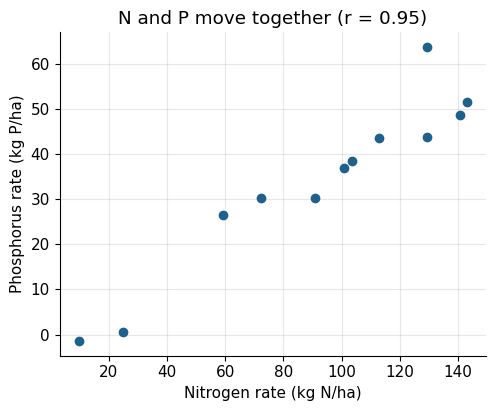

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3295.5601    239.260     13.774      0.000    2754.317    3836.803
N_rate_kg_ha    11.5419      7.321      1.576      0.149      -5.020      28.104
P_rate_kg_ha    29.0748     16.691      1.742      0.115      -8.682      66.832
R² = 0.928, overall F-test p = 7.1e-06


In [ ]:
data_B = pd.DataFrame({
    "N_rate_kg_ha": [
    9.7, 24.73, 59.36, 72.19, 90.81, 100.67, 103.62, 112.77,
    129.32, 129.47, 140.86, 142.96,
],
    "P_rate_kg_ha": [
    -1.42, 0.56, 26.37, 30.14, 30.19, 36.85, 38.53, 43.57,
    43.82, 63.66, 48.54, 51.5,
],
    "yield_kg_ha": [
    3399.28, 3709.67, 4688.42, 5182.1, 5100.57, 5426.3, 5785.37, 5214.12,
    5846.86, 6726.02, 6297.7, 7044.15,
],
})
r_NP = data_B.N_rate_kg_ha.corr(data_B.P_rate_kg_ha)

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.scatter(data_B.N_rate_kg_ha, data_B.P_rate_kg_ha, color=BLUE, zorder=3)
ax.set_xlabel("Nitrogen rate (kg N/ha)"); ax.set_ylabel("Phosphorus rate (kg P/ha)")
ax.set_title(f"N and P move together (r = {r_NP:.2f})")
plt.show()

res_b = smf.ols("yield_kg_ha ~ N_rate_kg_ha + P_rate_kg_ha", data_B).fit()
print(res_b.summary().tables[1])
print(f"R² = {res_b.rsquared:.3f}, overall F-test p = {res_b.f_pvalue:.1e}")

**Predict first.** The model explains 93% of the variation and the overall $F$-test is highly significant, yet *neither* slope's $p$-value is below 0.05. That mismatch is the signature of multicollinearity: together N and P predict yield, but the model cannot separate their individual effects. Now measure it.

In [ ]:
X_b = res_b.model.exog                       # design matrix, constant in column 0
names_b = res_b.model.exog_names
vif_sm = {nm: variance_inflation_factor(X_b, i) for i, nm in enumerate(names_b) if nm != "Intercept"}

# By hand: regress each predictor on the other one and use R_j²
aux_N = smf.ols("N_rate_kg_ha ~ P_rate_kg_ha", data_B).fit()
aux_P = smf.ols("P_rate_kg_ha ~ N_rate_kg_ha", data_B).fit()
vif_hand = {"N_rate_kg_ha": 1 / (1 - aux_N.rsquared), "P_rate_kg_ha": 1 / (1 - aux_P.rsquared)}

vif_table = pd.DataFrame({
    "R_j² (auxiliary)": [aux_N.rsquared, aux_P.rsquared],
    "VIF by hand": list(vif_hand.values()),
    "VIF statsmodels": [vif_sm[k] for k in vif_hand],
    "SE inflation √VIF": np.sqrt(list(vif_hand.values())),
}, index=list(vif_hand))
display(vif_table.round(3))

shortcut = 1 / (1 - r_NP ** 2)
print(f"Two-predictor shortcut: 1/(1 - r²) = 1/(1 - {r_NP:.3f}²) = {shortcut:.2f}")
assert np.isclose(vif_hand["N_rate_kg_ha"], vif_sm["N_rate_kg_ha"]) and np.isclose(shortcut, vif_hand["N_rate_kg_ha"])
print("VIF ≈ 10.8 is above the 'serious' threshold of 10: each standard error is about 3.3 times larger than it would be without the overlap.")

,R_j² (auxiliary),VIF by hand,VIF statsmodels,SE inflation √VIF
N_rate_kg_ha,0.908,10.836,10.836,3.292
P_rate_kg_ha,0.908,10.836,10.836,3.292


Two-predictor shortcut: 1/(1 - r²) = 1/(1 - 0.953²) = 10.84
VIF ≈ 10.8 is above the 'serious' threshold of 10: each standard error is about 3.3 times larger than it would be without the overlap.


**The `Cond. No.` field.** The bottom of the summary also reports a **condition number**. It warns about multicollinearity, but it is also inflated by predictors measured on very different scales. Standardizing the predictors (subtracting the mean and dividing by the SD) removes the scale effect and leaves only the collinearity.

In [ ]:
Z = (data_B[["N_rate_kg_ha", "P_rate_kg_ha"]] - data_B[["N_rate_kg_ha", "P_rate_kg_ha"]].mean()) / data_B[["N_rate_kg_ha", "P_rate_kg_ha"]].std()
res_b_std = sm.OLS(data_B.yield_kg_ha, sm.add_constant(Z)).fit()

print(f"Cond. No. (raw predictors)         : {res_b.condition_number:,.1f}")
print(f"Cond. No. (standardized predictors): {res_b_std.condition_number:,.1f}")
print("Most of the raw number comes from scale, not collinearity; VIF is the cleaner diagnostic.")

Cond. No. (raw predictors)         : 279.6
Cond. No. (standardized predictors): 6.4
Most of the raw number comes from scale, not collinearity; VIF is the cleaner diagnostic.


**Remedy.** The simplest fix is to drop one of the redundant predictors (other options: combine them into one index, center before adding polynomial terms, use PCA, or use Ridge/Lasso). Watch the standard error of N.

In [ ]:
res_b_drop = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data_B).fit()

pd.DataFrame({
    "N coef": [res_b.params["N_rate_kg_ha"], res_b_drop.params["N_rate_kg_ha"]],
    "N std err": [res_b.bse["N_rate_kg_ha"], res_b_drop.bse["N_rate_kg_ha"]],
    "N p-value": [res_b.pvalues["N_rate_kg_ha"], res_b_drop.pvalues["N_rate_kg_ha"]],
    "R²": [res_b.rsquared, res_b_drop.rsquared],
}, index=["N + P", "N only"]).round(4)

,N coef,N std err,N p-value,R²
N + P,11.5419,7.3215,0.1494,0.9283
N only,23.6928,2.4399,0.0000,0.9041


Dropping P cuts the standard error of N to about a third and N becomes strongly significant. But notice the **trade-off**: N's coefficient rose from about 11.5 to 23.7 because N now carries P's effect too, and $R^2$ dipped slightly. If you only need *predictions inside the observed range*, the original model was fine; the trouble was interpreting the individual coefficients.

### B.3 Independence of errors

**Assumption:** the errors are uncorrelated across observations. **Violation:** *autocorrelation* (serial or spatial). Here, neighboring field plots share soil conditions, so their errors move together. These tests only make sense when the rows have a **meaningful order** (time, or position in a field).

**Tests:**

- **Durbin–Watson (DW):** $DW = \dfrac{\sum_{t=2}^{n}(e_t-e_{t-1})^2}{\sum e_t^2} \approx 2(1-\hat\rho)$, where $\hat\rho$ is the correlation between consecutive residuals. DW near 2 means no autocorrelation, below 2 means positive, above 2 negative.
- **Breusch–Godfrey (BG):** regress the residuals on the original predictors *and* their own lags; then $LM = n\cdot R^2_{\text{aux}} \sim \chi^2(q)$ for $q$ lags. $H_0$: no serial correlation up to lag $q$. It works for any order and is generally preferred to DW.

*Dataset:* 20 plots in a row, nitrogen rates assigned in random order.

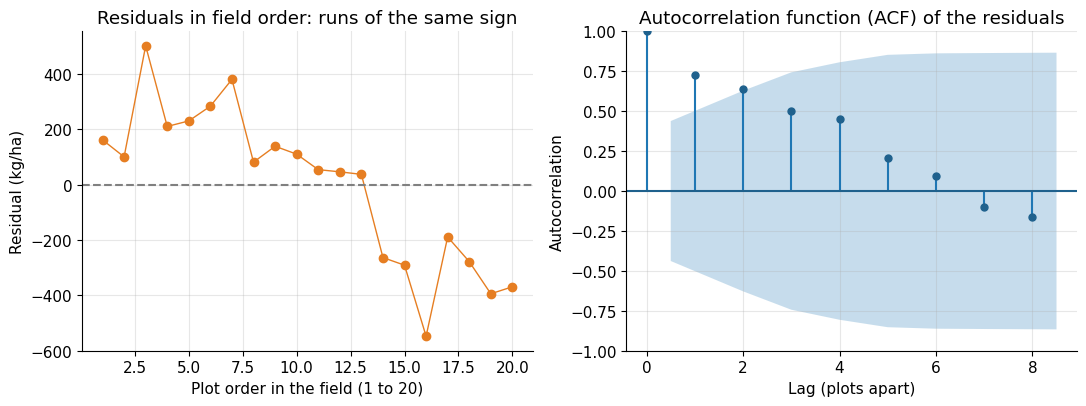

In [ ]:
data_C = pd.DataFrame({
    "plot_order": range(1, 21),
    "N_rate_kg_ha": [
    0, 0, 150, 50, 100, 100, 100, 0,
    50, 0, 50, 150, 100, 0, 100, 0,
    150, 150, 150, 100,
],
    "yield_kg_ha": [
    3434.98, 3373.52, 6740.87, 4472.21, 5480.91, 5534.19, 5631.03, 3354.44,
    4400.64, 3383.37, 4316.14, 6285.76, 5287.85, 3009.7, 4959.71, 2725.66,
    6050.39, 5961.33, 5845.19, 4881.65,
],
})
res_c = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data_C).fit()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(data_C.plot_order, res_c.resid, color=ORANGE, lw=1)
axes[0].scatter(data_C.plot_order, res_c.resid, color=ORANGE, zorder=3)
axes[0].axhline(0, color="gray", ls="--")
axes[0].set_xlabel("Plot order in the field (1 to 20)"); axes[0].set_ylabel("Residual (kg/ha)")
axes[0].set_title("Residuals in field order: runs of the same sign")
plot_acf(res_c.resid, lags=8, ax=axes[1], color=BLUE)
axes[1].set_xlabel("Lag (plots apart)"); axes[1].set_ylabel("Autocorrelation")
axes[1].set_title("Autocorrelation function (ACF) of the residuals")
fig.tight_layout()
plt.show()

**Predict first.** The residuals drift in long runs above and below zero, and the ACF bar at lag 1 sticks well out of the blue band (the band marks what chance alone would produce). Expect a DW well below 2. Compute DW and BG by hand, then with statsmodels.

In [ ]:
e = res_c.resid.to_numpy()

dw_hand = np.sum(np.diff(e) ** 2) / np.sum(e ** 2)
rho_hat = np.sum(e[1:] * e[:-1]) / np.sum(e ** 2)
print(f"Durbin-Watson by hand = {dw_hand:.3f}, statsmodels = {durbin_watson(e):.3f}")
print(f"Lag-1 autocorrelation ρ̂ = {rho_hat:.3f};  2(1 - ρ̂) = {2 * (1 - rho_hat):.3f}  (a rough approximation at n = 20)")
assert np.isclose(dw_hand, durbin_watson(e))

# Breusch-Godfrey with one lag, by hand: regress e_t on the predictors and e_{t-1}
lag1 = np.r_[0.0, e[:-1]]                         # first lag is padded with 0
aux = sm.OLS(e, np.column_stack([res_c.model.exog, lag1])).fit()
LM = len(e) * aux.rsquared
lm_sm, lm_p_sm, _, _ = acorr_breusch_godfrey(res_c, nlags=1)
print(f"\nBreusch-Godfrey by hand: LM = {LM:.2f}, p = {stats.chi2.sf(LM, 1):.2g}")
print(f"Breusch-Godfrey statsmodels: LM = {lm_sm:.2f}, p = {lm_p_sm:.2g}")
assert np.isclose(LM, lm_sm)
print("\nDW is far below 2 and BG rejects H0 (p < 0.001): the errors are positively autocorrelated.")

Durbin-Watson by hand = 0.441, statsmodels = 0.441
Lag-1 autocorrelation ρ̂ = 0.726;  2(1 - ρ̂) = 0.548  (a rough approximation at n = 20)

Breusch-Godfrey by hand: LM = 13.44, p = 0.00025
Breusch-Godfrey statsmodels: LM = 13.44, p = 0.00025

DW is far below 2 and BG rejects H0 (p < 0.001): the errors are positively autocorrelated.


**Why does it matter?** Autocorrelated errors leave the coefficients unbiased but make the OLS standard errors unreliable. The lecture said they are *understated*, which inflates $t$ and creates false "significance". Let us check that claim with a simulation instead of taking it on faith. We build 500 datasets where the **true slope is zero** and the errors are autocorrelated ($\rho=0.8$), and count how often a 5%-level $t$-test falsely finds a slope. A trustworthy test should be wrong about 5% of the time. We try two layouts of the predictor: nitrogen assigned in **random order**, and a predictor that **trends** with plot position.

In [ ]:
def false_positive_rate(design, n_sims=500, rho=0.8, n_obs=20):
    # Share of datasets (true slope = 0) where the t-test falsely rejects at 5%.
    pos = np.arange(1, n_obs + 1, dtype=float)
    naive = hac = 0
    for sim in range(n_sims):
        rng = np.random.default_rng(1000 + sim)
        eps = rng.normal(0, 150, n_obs)
        err = np.zeros(n_obs)
        for i in range(n_obs):
            err[i] = (rho * err[i - 1] if i > 0 else 0) + eps[i]
        xx = rng.permutation(np.tile([0, 50, 100, 150.], n_obs // 4)) if design == "random order" else pos
        yy = 3200 + err                               # true slope = 0
        X = sm.add_constant(xx)
        naive += sm.OLS(yy, X).fit().pvalues[1] < 0.05
        hac += sm.OLS(yy, X).fit(cov_type="HAC", cov_kwds={"maxlags": 3}).pvalues[1] < 0.05
    return naive / n_sims, hac / n_sims

sim_rows = []
for design in ["random order", "trends with position"]:
    nv, hc = false_positive_rate(design)
    sim_rows.append({"predictor layout": design, "naive OLS SEs": nv, "HAC (Newey-West) SEs": hc})
sim = pd.DataFrame(sim_rows).set_index("predictor layout")
display((sim * 100).round(1).astype(str) + "%")
print("A trustworthy 5% test should show about 5%.")

assert 0.02 < sim.loc["random order", "naive OLS SEs"] < 0.09
assert sim.loc["trends with position", "naive OLS SEs"] > 0.30
# guard the numbers quoted in the text below
assert 0.44 < sim.loc["trends with position", "naive OLS SEs"] < 0.52
assert 0.10 < sim.loc["random order", "HAC (Newey-West) SEs"] < 0.20

,naive OLS SEs,HAC (Newey-West) SEs
predictor layout,,
random order,4.8%,15.2%
trends with position,48.2%,47.4%


A trustworthy 5% test should show about 5%.


**What the simulation shows:**

- When the predictor is assigned in **random order**, the naive test is fine (about 5%): the autocorrelation barely affects the slope's standard error.
- When the predictor **trends along the same order as the errors**, the naive test is badly fooled: about **48% false positives** instead of 5%. The standard errors really are understated, and the conclusion "N has an effect" would often be wrong.
- **HAC standard errors do not rescue us here.** They are a *large-sample* correction: with only 20 observations they leave the trending layout at about 47% and make the random layout *worse* (about 15%).

**So the best remedy is at the design stage:** randomize (and block) treatments so the predictor is not aligned with field position. Once the data are in hand, the next best is to model the error structure explicitly, for example with an AR(1) error model (`GLSAR`, a Cochrane–Orcutt-style estimator), as below.

In [ ]:
glsar = sm.GLSAR(data_C["yield_kg_ha"], sm.add_constant(data_C[["N_rate_kg_ha"]]), rho=1).iterative_fit(maxiter=10)

display(pd.DataFrame({
    "slope": [res_c.params["N_rate_kg_ha"], glsar.params["N_rate_kg_ha"]],
    "std err": [res_c.bse["N_rate_kg_ha"], glsar.bse["N_rate_kg_ha"]],
}, index=["OLS (ignores autocorrelation)", "GLSAR (AR(1) errors)"]).round(3))

print(f"Estimated error autocorrelation ρ = {float(glsar.model.rho[0]):.2f}")
print("The data were generated with a true slope of 22 kg/ha per kg N, so we can check:")
print(f"  OLS slope   = {res_c.params['N_rate_kg_ha']:.2f}")
print(f"  GLSAR slope = {glsar.params['N_rate_kg_ha']:.2f}")

,slope,std err
OLS (ignores autocorrelation),19.775,1.116
GLSAR (AR(1) errors),21.698,0.341


Estimated error autocorrelation ρ = 0.90
The data were generated with a true slope of 22 kg/ha per kg N, so we can check:
  OLS slope   = 19.77
  GLSAR slope = 21.70


Accounting for the autocorrelation moves the slope from about 19.8 to 21.7 (closer to the true 22 that generated the data) and shrinks its standard error by about two thirds. Here OLS was not just misreported; it was **inefficient**, which is the Gauss–Markov warning in action: with correlated errors, OLS is no longer the *best* linear unbiased estimator. A caution, though: with only 20 plots the AR(1) correlation itself is estimated noisily, so GLSAR's standard errors can still be optimistic. Randomizing the layout remains the best protection.

### B.4 Homoscedasticity (constant variance)

**Assumption:** $\operatorname{Var}(\varepsilon_i)=\sigma^2$ for every observation. **Violation:** *heteroskedasticity*, for example yield becoming more variable at high nitrogen rates.

**Plot:** residuals vs. fitted; a fan or funnel shape means the spread changes with the fitted value.

**Tests** (both: regress the *squared* residuals on something, then $LM = n\cdot R^2_{\text{aux}}\sim\chi^2$; $H_0$: constant variance):

- **Breusch–Pagan (BP):** regress $e_i^2$ on the predictors. Detects variance that changes *linearly* with them.
- **White:** regress $e_i^2$ on the predictors, their squares, and cross-products. Needs no assumed form, but costs more degrees of freedom as predictors grow.

*Dataset:* 30 plots where the spread of yield grows with the nitrogen rate.

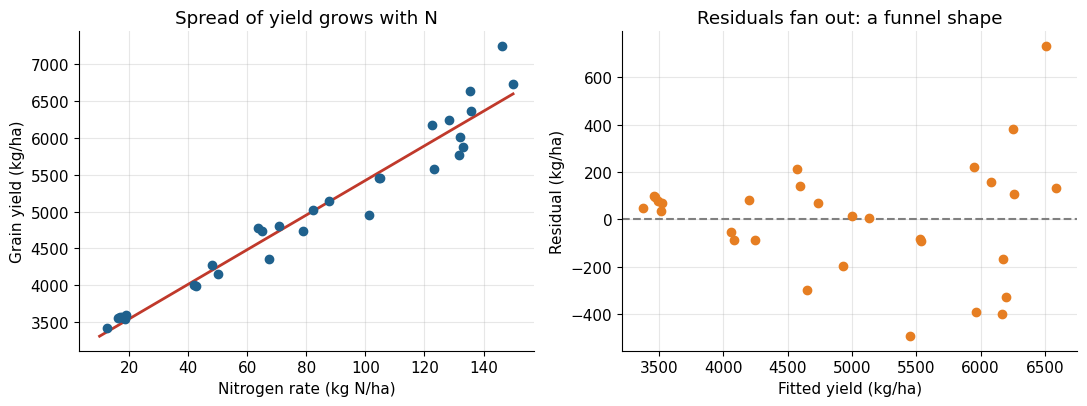

In [ ]:
data_D = pd.DataFrame({
    "N_rate_kg_ha": [
    12.6, 16.3, 16.8, 17.6, 18.5, 19.0, 41.8, 42.8,
    48.0, 50.0, 63.7, 64.9, 67.2, 70.9, 79.0, 82.1,
    87.8, 101.3, 104.7, 105.1, 122.7, 123.1, 128.2, 131.8,
    132.1, 133.2, 135.4, 135.7, 146.4, 149.9,
],
    "yield_kg_ha": [
    3421.97, 3560.5, 3568.2, 3569.79, 3548.87, 3595.29, 4003.35, 3994.26,
    4283.18, 4161.57, 4782.26, 4741.73, 4352.83, 4806.16, 4730.45, 5013.67,
    5140.32, 4956.19, 5446.92, 5448.91, 6173.52, 5570.75, 6239.45, 5764.7,
    6005.11, 5870.52, 6631.14, 6362.97, 7240.11, 6718.76,
],
})
res_d = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data_D).fit()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(data_D.N_rate_kg_ha, data_D.yield_kg_ha, color=BLUE, zorder=3)
grid = np.array([10, 150])
axes[0].plot(grid, res_d.params.iloc[0] + res_d.params.iloc[1] * grid, color=RED, lw=2)
axes[0].set_xlabel("Nitrogen rate (kg N/ha)"); axes[0].set_ylabel("Grain yield (kg/ha)")
axes[0].set_title("Spread of yield grows with N")
axes[1].scatter(res_d.fittedvalues, res_d.resid, color=ORANGE, zorder=3)
axes[1].axhline(0, color="gray", ls="--")
axes[1].set_xlabel("Fitted yield (kg/ha)"); axes[1].set_ylabel("Residual (kg/ha)")
axes[1].set_title("Residuals fan out: a funnel shape")
fig.tight_layout()
plt.show()

**Predict first.** The residual plot is a funnel, so expect both tests to reject. Build each test by hand (the auxiliary regression of $e^2$), then compare with statsmodels.

In [ ]:
e2 = res_d.resid.to_numpy() ** 2
exog = res_d.model.exog                                   # [constant, N]
n_d = len(e2)

# Breusch-Pagan by hand: e² on the predictors
bp_lm = n_d * sm.OLS(e2, exog).fit().rsquared
bp_sm = het_breuschpagan(res_d.resid, exog)

# White by hand: e² on the predictors, their squares (and cross-products when there are several)
exog_white = np.column_stack([exog, exog[:, 1] ** 2])
w_lm = n_d * sm.OLS(e2, exog_white).fit().rsquared
w_sm = het_white(res_d.resid, exog)

pd.DataFrame({
    "LM by hand": [bp_lm, w_lm],
    "LM statsmodels": [bp_sm[0], w_sm[0]],
    "df": [1, 2],
    "p-value": [stats.chi2.sf(bp_lm, 1), stats.chi2.sf(w_lm, 2)],
}, index=["Breusch-Pagan", "White"]).round(4)

assert np.isclose(bp_lm, bp_sm[0]) and np.isclose(w_lm, w_sm[0])
print(f"Breusch-Pagan: LM = {bp_lm:.2f}, p = {stats.chi2.sf(bp_lm, 1):.4f}")
print(f"White        : LM = {w_lm:.2f}, p = {stats.chi2.sf(w_lm, 2):.4f}")
print("Both p-values are below 0.05: reject H0 of constant variance.")

Breusch-Pagan: LM = 6.69, p = 0.0097
White        : LM = 7.87, p = 0.0196
Both p-values are below 0.05: reject H0 of constant variance.


**Consequences and remedies.** With heteroskedasticity the coefficients stay unbiased but OLS is no longer efficient, and the usual standard errors are biased, so the $t$-tests and confidence intervals are invalid. Two common remedies:

- **Robust standard errors** (White/HC): keep the OLS coefficients but fix the standard errors. `cov_type="HC3"` is a good default for small samples.
- **Weighted least squares (WLS):** give noisy observations less weight, using weights $1/\sigma_i^2$. You must model the variance; here the variance clearly grows with N, so we try weights $1/N^2$.

In [ ]:
res_d_hc3 = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data_D).fit(cov_type="HC3")
res_d_wls = smf.wls("yield_kg_ha ~ N_rate_kg_ha", data_D, weights=1 / data_D.N_rate_kg_ha ** 2).fit()

rows = []
for name, r in [("OLS (naive SEs)", res_d), ("OLS + HC3 robust SEs", res_d_hc3), ("WLS (weights 1/N²)", res_d_wls)]:
    lo, hi = r.conf_int().loc["N_rate_kg_ha"]
    rows.append({"model": name, "slope": r.params["N_rate_kg_ha"], "std err": r.bse["N_rate_kg_ha"],
                 "95% CI low": lo, "95% CI high": hi})
display(pd.DataFrame(rows).set_index("model").round(3))
print("The true slope used to generate the data is 22 kg/ha per kg N.")

,slope,std err,95% CI low,95% CI high
model,,,,
OLS (naive SEs),23.406,1.014,21.330,25.483
OLS + HC3 robust SEs,23.406,1.179,21.096,25.716
WLS (weights 1/N²),22.183,0.654,20.843,23.523


The true slope used to generate the data is 22 kg/ha per kg N.


The robust (HC3) standard error is about 16% larger than the naive one: the naive intervals were too narrow. WLS changes the slope itself and gives the smallest SE, but only if the variance model (here $\propto N^2$) is right, which in real life you must justify. If you are unsure, robust SEs are the safer choice.

### B.5 Normality of errors

**Assumption:** $\varepsilon_i\sim N(0,\sigma^2)$. It concerns the **errors**, not the distributions of $x$ or $y$. **Violation:** skewness (lopsided) or heavy tails (excess kurtosis).

**Plots:** a histogram of the residuals and a **Q–Q plot** (residual quantiles against normal quantiles; points near the diagonal mean approximately normal).

**Tests** ($H_0$: the errors are normal):

- **Shapiro–Wilk (SW):** $W$ near 1 means normal. Best for small to moderate $n$; very sensitive at large $n$.
- **Jarque–Bera (JB):** $JB = \dfrac{n}{6}\left[S^2+\dfrac{(K-3)^2}{4}\right]\sim\chi^2(2)$, with $S$ the skewness (0 if symmetric) and $K$ the kurtosis (3 if normal). It is asymptotic, so it works best for large $n$.

*Dataset:* 40 plots with heavy-tailed errors.

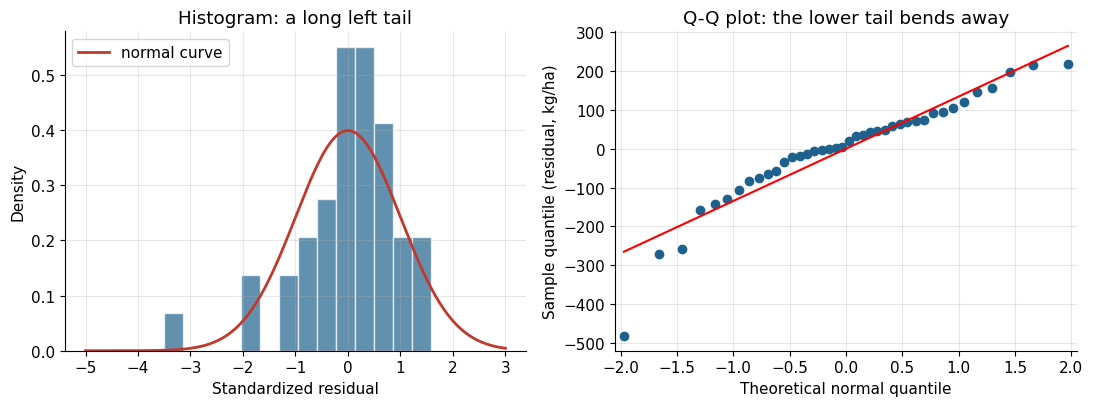

In [ ]:
data_E = pd.DataFrame({
    "N_rate_kg_ha": [
    93.8, 134.6, 116.4, 33.8, 45.0, 131.0, 0.8, 123.2,
    119.6, 70.2, 45.5, 41.8, 38.2, 66.8, 75.7, 83.0,
    149.3, 118.9, 93.3, 148.3, 32.3, 24.0, 91.9, 6.6,
    5.4, 77.2, 69.9, 137.6, 94.4, 77.1, 74.5, 37.1,
    1.8, 28.9, 103.8, 30.1, 55.4, 0.6, 124.5, 23.2,
],
    "yield_kg_ha": [
    5249.26, 6009.5, 5625.56, 3905.89, 4042.3, 6065.12, 3263.99, 5944.03,
    5616.53, 4813.98, 4124.74, 4056.15, 4147.24, 4651.78, 4832.22, 4973.63,
    6450.97, 5813.52, 5388.72, 6323.8, 3601.22, 3737.56, 5149.12, 3319.67,
    3448.14, 4908.14, 4667.31, 6242.86, 4732.61, 4711.0, 5003.67, 4069.86,
    3430.66, 3796.67, 5412.06, 3667.58, 4406.66, 3105.42, 5940.42, 3419.32,
],
})
res_e = smf.ols("yield_kg_ha ~ N_rate_kg_ha", data_E).fit()
z_e = res_e.resid / res_e.resid.std(ddof=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(z_e, bins=14, density=True, color=BLUE, alpha=0.7, edgecolor="white")
grid = np.linspace(-5, 3, 200)
axes[0].plot(grid, stats.norm.pdf(grid), color=RED, lw=2, label="normal curve")
axes[0].set_xlabel("Standardized residual"); axes[0].set_ylabel("Density")
axes[0].set_title("Histogram: a long left tail"); axes[0].legend()
sm.qqplot(res_e.resid, line="s", ax=axes[1], markerfacecolor=BLUE, markeredgecolor=BLUE)
axes[1].set_xlabel("Theoretical normal quantile"); axes[1].set_ylabel("Sample quantile (residual, kg/ha)")
axes[1].set_title("Q-Q plot: the lower tail bends away")
fig.tight_layout()
plt.show()

**Predict first.** The Q–Q plot's lowest points sit far below the line, which signals a heavy, lopsided lower tail. Expect both tests to reject. Compute JB from skewness and kurtosis by hand, then use statsmodels and scipy.

In [ ]:
e = res_e.resid.to_numpy()
n_e = len(e)

S = stats.skew(e)
K = stats.kurtosis(e, fisher=False)             # 3 for a normal distribution
JB = n_e / 6 * (S ** 2 + (K - 3) ** 2 / 4)
jb_sm = jarque_bera(e)
omni = omni_normtest(e)
sw = stats.shapiro(e)

print(f"Skewness S = {S:.3f}   Kurtosis K = {K:.3f}")
print(f"Jarque-Bera  by hand: {JB:.2f} (p = {stats.chi2.sf(JB, 2):.2g});  statsmodels: {jb_sm[0]:.2f} (p = {jb_sm[1]:.2g})")
print(f"Omnibus (also in the summary): {omni.statistic:.2f} (p = {omni.pvalue:.2g})")
print(f"Shapiro-Wilk: W = {sw.statistic:.3f} (p = {sw.pvalue:.4f})")

assert np.isclose(JB, jb_sm[0]) and np.isclose(S, jb_sm[2]) and np.isclose(K, jb_sm[3])
print("\nAll p-values are below 0.05: reject H0. The errors are not normal (skewed and heavy-tailed).")

Skewness S = -1.227   Kurtosis K = 5.597
Jarque-Bera  by hand: 21.27 (p = 2.4e-05);  statsmodels: 21.27 (p = 2.4e-05)
Omnibus (also in the summary): 16.28 (p = 0.00029)
Shapiro-Wilk: W = 0.918 (p = 0.0067)

All p-values are below 0.05: reject H0. The errors are not normal (skewed and heavy-tailed).


**Consequences and remedies.** The coefficients stay BLUE, but $t$/$F$ tests, confidence intervals, and prediction intervals rely on normality in *small samples*. The central limit theorem softens this as $n$ grows. First check for data errors and outliers; then consider transforming $y$ (log, square root) or a **bootstrap** confidence interval, which makes no normality assumption: resample the plots with replacement, refit, and read the percentiles of the slopes.

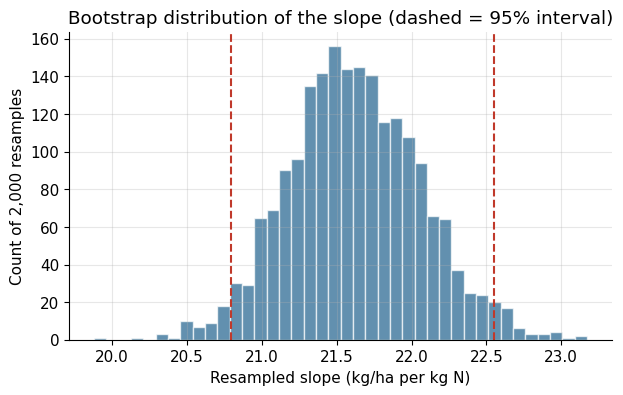

Slope estimate  : 21.61
Classic 95% CI  : [20.61, 22.61]
Bootstrap 95% CI: [20.79, 22.55]


In [ ]:
rng = np.random.default_rng(42)
xs, ys = data_E.N_rate_kg_ha.to_numpy(), data_E.yield_kg_ha.to_numpy()
boot = np.array([np.polyfit(xs[idx], ys[idx], 1)[0]
                 for idx in (rng.integers(0, n_e, n_e) for _ in range(2000))])

boot_ci = np.percentile(boot, [2.5, 97.5])
classic_ci = res_e.conf_int().loc["N_rate_kg_ha"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot, bins=40, color=BLUE, alpha=0.7, edgecolor="white")
for v in boot_ci:
    ax.axvline(v, color=RED, ls="--")
ax.set_xlabel("Resampled slope (kg/ha per kg N)"); ax.set_ylabel("Count of 2,000 resamples")
ax.set_title("Bootstrap distribution of the slope (dashed = 95% interval)")
plt.show()

print(f"Slope estimate  : {res_e.params['N_rate_kg_ha']:.2f}")
print(f"Classic 95% CI  : [{classic_ci[0]:.2f}, {classic_ci[1]:.2f}]")
print(f"Bootstrap 95% CI: [{boot_ci[0]:.2f}, {boot_ci[1]:.2f}]")

The two intervals nearly agree. With $n = 40$ the central limit theorem is already doing most of the work, so even though the residuals clearly fail the normality tests, the slope's $t$-based interval is still serviceable. **Non-normality is mostly a small-sample worry**, and a failed normality test is a prompt to look for outliers and consider the bootstrap, not an automatic disaster.

### B.6 The bottom of the summary, decoded

You now know every field in the last block of `results.summary()`. Here it is for the heavy-tailed model, with each field matched to what you computed:

| Field | What it is | Where you computed it |
|---|---|---|
| **Omnibus**, **Prob(Omnibus)** | A normality test based on skewness and kurtosis | B.5 (`omni_normtest`) |
| **Skew**, **Kurtosis** | $S$ and $K$ of the residuals | B.5 |
| **Jarque-Bera (JB)**, **Prob(JB)** | The JB test | B.5 |
| **Durbin-Watson** | The DW statistic (meaningful only if rows have an order) | B.3 |
| **Cond. No.** | Condition number: scale plus collinearity | B.2 |

In [ ]:
print(res_e.summary())

                            OLS Regression Results                            
Dep. Variable:            yield_kg_ha   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     1922.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           3.75e-34
Time:                        06:56:32   Log-Likelihood:                -252.83
No. Observations:                  40   AIC:                             509.7
Df Residuals:                      38   BIC:                             513.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3175.1140     41.093     77.266   

## Part C: The Whole Checklist on Real Data (Palmer Penguins)

Real data are not built to show one clean violation. Let us run every test from Part B on a real model: penguin body mass predicted from flipper length, bill length, and bill depth (Gorman et al., 2014; Horst, Hill & Gorman, 2020).

First, a reusable function that runs the lecture's whole checklist on any fitted statsmodels OLS result. Independence tests are **skipped unless you say the rows have a meaningful order**.

In [ ]:
def diagnose(results, ordered=False, alpha=0.05):
    # Run the lecture's assumption checklist on a fitted statsmodels OLS result.
    X, names = results.model.exog, results.model.exog_names
    rows = []

    def add(assumption, test, stat, pval, note=None):
        if pval is None:
            reading = note
        else:
            reading = "REJECT H0: assumption violated" if pval < alpha else "no evidence against"
        rows.append({"assumption": assumption, "test": test, "statistic": stat, "p-value": pval, "reading": reading})

    r = linear_reset(results, power=2, use_f=True)
    add("Linearity", "Ramsey RESET (F)", float(r.fvalue), float(r.pvalue))

    pred_cols = [i for i, nm in enumerate(names) if nm not in ("Intercept", "const")]
    if len(pred_cols) >= 2:
        worst = max(variance_inflation_factor(X, i) for i in pred_cols)
        note = "serious (>10)" if worst > 10 else "concern (>5)" if worst > 5 else "fine (<5)"
        add("Multicollinearity", "largest VIF", worst, None, note)
    else:
        add("Multicollinearity", "VIF", np.nan, None, "needs 2+ predictors")

    if ordered:
        add("Independence", "Durbin-Watson", float(durbin_watson(results.resid)), None, "near 2 = no autocorrelation")
        bg = acorr_breusch_godfrey(results, nlags=1)
        add("Independence", "Breusch-Godfrey (LM, 1 lag)", float(bg[0]), float(bg[1]))
    else:
        add("Independence", "(skipped)", np.nan, None, "rows have no meaningful order")

    bp, wt = het_breuschpagan(results.resid, X), het_white(results.resid, X)
    add("Constant variance", "Breusch-Pagan (LM)", float(bp[0]), float(bp[1]))
    add("Constant variance", "White (LM)", float(wt[0]), float(wt[1]))

    jb, sw = jarque_bera(results.resid), stats.shapiro(results.resid)
    add("Normality", "Jarque-Bera", float(jb[0]), float(jb[1]))
    add("Normality", "Shapiro-Wilk (W)", float(sw.statistic), float(sw.pvalue))

    out = pd.DataFrame(rows)
    out["statistic"] = out["statistic"].map(lambda v: "" if pd.isna(v) else f"{v:.3f}")
    out["p-value"] = out["p-value"].map(lambda v: "" if pd.isna(v) else f"{v:.3g}")
    return out

print("diagnose() defined: pass it any fitted OLS result.")

diagnose() defined: pass it any fitted OLS result.


In [ ]:
URL = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
penguins = pd.read_csv(URL)
cols = ["body_mass_g", "flipper_length_mm", "bill_length_mm", "bill_depth_mm"]
d = penguins.dropna(subset=cols).reset_index(drop=True)

res_p = smf.ols("body_mass_g ~ flipper_length_mm + bill_length_mm + bill_depth_mm", data=d).fit()
print(f"n = {len(d)} penguins,  R² = {res_p.rsquared:.4f},  adjusted R² = {res_p.rsquared_adj:.4f}\n")
display(diagnose(res_p, ordered=False))

n = 342 penguins,  R² = 0.7615,  adjusted R² = 0.7594



,assumption,test,statistic,p-value,reading
0,Linearity,Ramsey RESET (F),23.126,2.29e-06,REJECT H0: assumption violated
1,Multicollinearity,largest VIF,2.673,,fine (<5)
2,Independence,(skipped),,,rows have no meaningful order
3,Constant variance,Breusch-Pagan (LM),3.572,0.311,no evidence against
4,Constant variance,White (LM),12.049,0.211,no evidence against
5,Normality,Jarque-Bera,5.129,0.077,no evidence against
6,Normality,Shapiro-Wilk (W),0.994,0.164,no evidence against


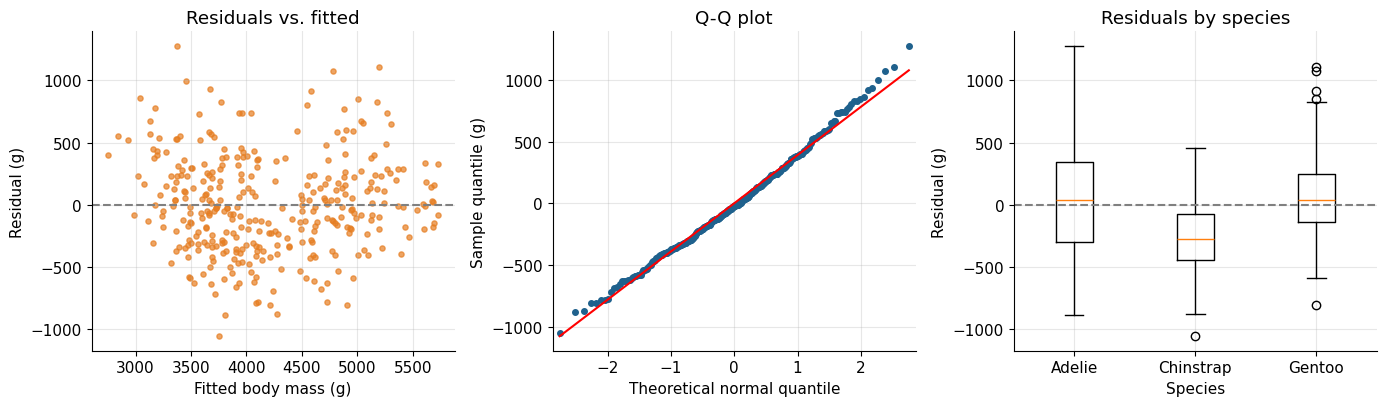

            mean    std  count
species                       
Adelie      47.3  408.6    151
Chinstrap -258.6  314.1     68
Gentoo      84.9  349.3    123


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].scatter(res_p.fittedvalues, res_p.resid, color=ORANGE, s=14, alpha=0.7)
axes[0].axhline(0, color="gray", ls="--")
axes[0].set_xlabel("Fitted body mass (g)"); axes[0].set_ylabel("Residual (g)")
axes[0].set_title("Residuals vs. fitted")

sm.qqplot(res_p.resid, line="s", ax=axes[1], markerfacecolor=BLUE, markeredgecolor=BLUE, markersize=4)
axes[1].set_xlabel("Theoretical normal quantile"); axes[1].set_ylabel("Sample quantile (g)")
axes[1].set_title("Q-Q plot")

species = ["Adelie", "Chinstrap", "Gentoo"]
axes[2].boxplot([res_p.resid[d.species == sp] for sp in species])
axes[2].set_xticklabels(species)
axes[2].axhline(0, color="gray", ls="--")
axes[2].set_xlabel("Species"); axes[2].set_ylabel("Residual (g)")
axes[2].set_title("Residuals by species")
fig.tight_layout()
plt.show()

print(d.assign(residual_g=res_p.resid).groupby("species")["residual_g"].agg(["mean", "std", "count"]).round(1))

**Reading the results honestly:**

- **Multicollinearity: fine.** The largest VIF is about 2.7, well under 5, so the three predictors are not redundant.
- **Constant variance: no evidence against.** Breusch–Pagan ($p \approx 0.31$) and White ($p \approx 0.21$) do not reject.
- **Normality: no evidence against.** Jarque–Bera ($p \approx 0.08$) and Shapiro–Wilk ($p \approx 0.16$) do not reject, although the Jarque–Bera $p$-value is not far from 0.05.
- **Linearity: RESET rejects** ($F \approx 23$, $p < 0.001$). The functional form is off somewhere. The residuals-by-species panel hints at why: Chinstrap penguins sit about 259 g *below* the model on average while Adelie and Gentoo sit above. **Species, which is not in the model, carries structure the model misses** (this is consistent with the RESET result; it does not prove it is the only cause). That is a motivation for Notebook 02-03, where we learn to put more kinds of predictors into a model.

**A note on independence.** The penguin rows have no meaningful order (they are a sample of birds, not a time series), so `diagnose` skipped Durbin–Watson and Breusch–Godfrey. To see why, compute DW on the rows in file order and again on a random shuffle.

In [ ]:
resid_file_order = res_p.resid.to_numpy()
resid_shuffled = res_p.resid.sample(frac=1, random_state=0).to_numpy()

print(f"Durbin-Watson, rows in file order: {durbin_watson(resid_file_order):.3f}")
print(f"Durbin-Watson, rows shuffled     : {durbin_watson(resid_shuffled):.3f}")

assert abs(durbin_watson(resid_file_order) - 2) < 0.2 and abs(durbin_watson(resid_shuffled) - 2) < 0.2
print("\nThe statistic depends on an arbitrary row order. Both happen to look fine here, but neither means anything:")
print("autocorrelation tests are only meaningful when the order of the observations is real (time or position).")

Durbin-Watson, rows in file order: 2.030
Durbin-Watson, rows shuffled     : 1.954

The statistic depends on an arbitrary row order. Both happen to look fine here, but neither means anything:
autocorrelation tests are only meaningful when the order of the observations is real (time or position).


## Part D: Independent Practice (Restaurant Tips)

Apply the full checklist to a dataset you know from Notebook 01-03: tips left at a restaurant (`tips`, from the seaborn data repository). Does the size of the bill predict the tip?

**Your tasks:**

1. Fit `tip ~ total_bill` with the formula interface. Report $R^2$, the slope, and its 95% confidence interval.
2. Run `diagnose(model, ordered=False)` and identify **which assumptions are violated** (tip: look at the residual-vs-fitted plot first and say what you expect).
3. Apply **one** remedy from Part B (robust standard errors, or a log transform of both variables) and show it addressed the violation you found.
4. Write three sentences: what does the slope mean in dollars, what is wrong with the plain OLS standard errors, and what did your remedy fix (and not fix)?

In [ ]:
tips = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
print(f"{len(tips)} meals;  columns: {list(tips.columns)}")
display(tips.head())

# YOUR WORK BELOW
# Task 1: res_t = smf.ols("tip ~ total_bill", data=tips).fit()
# Task 2: residual plot, then diagnose(res_t, ordered=False)
# Task 3: remedy (cov_type="HC3", or smf.ols("np.log(tip) ~ np.log(total_bill)", data=tips))

244 meals;  columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Checkpoints (check your work against these)

| Check | Value |
|---|---|
| Sample size | 244 meals |
| Fitted line | tip $\approx$ 0.920 + 0.1050 · total_bill (about 10.5 cents per dollar of bill) |
| $R^2$ / adjusted $R^2$ | 0.4566 / 0.4544 |
| RESET (linearity) | $p \approx 0.92$: no evidence against |
| Breusch–Pagan / White | $p \approx 4.5\times10^{-12}$ and $9.6\times10^{-14}$: **heteroskedasticity** |
| Jarque–Bera / Shapiro–Wilk | $p \approx 6.3\times10^{-9}$ and $2.2\times10^{-5}$: **non-normal** (right-skewed, $S\approx0.44$, $K\approx4.7$) |
| Slope SE: naive vs. HC3 | 0.0074 vs. 0.0121: the naive SE is about 40% too small |
| Log–log model | elasticity about 0.675, $R^2\approx0.462$; Breusch–Pagan $p\approx0.13$ (variance problem fixed), RESET $p\approx0.84$, but Jarque–Bera $p\approx1.4\times10^{-5}$ and Shapiro–Wilk $p\approx0.009$ (**non-normality remains**) |

**What to notice:** the straight line is fine for the *mean* (RESET passes), but bigger bills produce more variable tips, so the usual standard errors are too small. HC3 repairs the standard errors; the log–log model repairs the variance pattern but not the skewed residuals. A remedy rarely fixes everything, and saying clearly what it did *not* fix is part of an honest analysis.

---
## Summary and What Comes Next

| Assumption | Look at | Test (function) | $H_0$ | Typical remedy |
|---|---|---|---|---|
| Linearity | Residuals vs. fitted | `linear_reset` | Form is correct | Add $N^2$, transform |
| No multicollinearity | Correlation, scale-free | `variance_inflation_factor` | (measure, not a test) | Drop/combine, Ridge/Lasso |
| Independent errors | Residuals in order, ACF | `durbin_watson`, `acorr_breusch_godfrey` | No autocorrelation | Randomize, `GLSAR`, HAC (large $n$) |
| Constant variance | Residuals vs. fitted | `het_breuschpagan`, `het_white` | Constant variance | HC3 robust SEs, WLS, transform |
| Normal errors | Q–Q plot, histogram | `jarque_bera`, `scipy.stats.shapiro` | Errors are normal | Check outliers, transform, bootstrap |

**Remember:** a small $p$-value on an assumption test is the *bad* news; a large one is only "no evidence against". Plot first, test second, and report what your remedy did not fix.

**Next: Notebook 02-03** moves from one predictor to several: multiple linear regression.

---
**References.** Anscombe, F. J. (1973). Graphs in statistical analysis. *The American Statistician, 27*(1), 17–21. · Ramsey, J. B. (1969). Tests for specification errors in classical linear least-squares regression analysis. *JRSS B, 31*(2), 350–371. · Durbin, J., & Watson, G. S. (1950, 1951). Testing for serial correlation in least squares regression I, II. *Biometrika, 37*, 409–428; *38*, 159–178. · Breusch, T. S. (1978). Testing for autocorrelation in dynamic linear models. *Australian Economic Papers, 17*, 334–355. · Godfrey, L. G. (1978). Testing against general autoregressive and moving average error models when the regressors include lagged dependent variables. *Econometrica, 46*, 1293–1301. · Breusch, T. S., & Pagan, A. R. (1979). A simple test for heteroscedasticity and random coefficient variation. *Econometrica, 47*, 1287–1294. · White, H. (1980). A heteroskedasticity-consistent covariance matrix estimator and a direct test for heteroskedasticity. *Econometrica, 48*, 817–838. · Shapiro, S. S., & Wilk, M. B. (1965). An analysis of variance test for normality (complete samples). *Biometrika, 52*, 591–611. · Jarque, C. M., & Bera, A. K. (1980). Efficient tests for normality, homoscedasticity and serial independence of regression residuals. *Economics Letters, 6*, 255–259. · Akaike, H. (1974). A new look at the statistical model identification. *IEEE Transactions on Automatic Control, 19*, 716–723. · Schwarz, G. (1978). Estimating the dimension of a model. *Annals of Statistics, 6*, 461–464. · Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*. · Gorman, K. B., Williams, T. D., & Fraser, W. R. (2014). Ecological sexual dimorphism and environmental variability within a community of Antarctic penguins (genus *Pygoscelis*). *PLoS ONE, 9*(3), e90081. · Horst, A. M., Hill, A. P., & Gorman, K. B. (2020). palmerpenguins: Palmer Archipelago (Antarctica) penguin data. R package version 0.1.0. https://doi.org/10.5281/zenodo.3960218

© 2026 Engr. Dylan Josh D. Lopez. All rights reserved.